In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import palettable, argparse
import numpy as np
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib as mpl
import os, glob

# List all available fonts
file_paths = glob.glob( "/home/goldpm1/miniconda3/envs/cnvpytor/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/arial*" )
absolute_file_paths = [os.path.abspath(file_path) for file_path in file_paths]
for absolute_file_path in absolute_file_paths:
    mpl.font_manager.fontManager.addfont( absolute_file_path )
plt.rcParams["font.family"] = 'Arial'

# Visualization palette
tabl = palettable.tableau.Tableau_20.mpl_colors
vivid_10 = palettable.cartocolors.qualitative.Vivid_10.mpl_colors
colorlist_PC = ["#323233"]  * 3 # ["#2f4858", "#7288C6", "#BCA97B" ]
colorlist_PT = ["#323233"] * 3  # ["#86bbd8" , "#7288C6", "#BCA97B" ]

PYCLONEVIpath="/data/project/Meningioma/31.Clonality"


## Scaled visualization

In [10]:
def legend_without_duplicate_labels( ax, **kwargs ):
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique), fontsize = kwargs["legend_fontsize"], markerscale = kwargs["legend_markerscale"], bbox_to_anchor=(1.02, 0.5), frameon=False)



def visualization_decomposition( df, ax, **kwargs  ):
    #ax.text(0.5, 0.9, "Purity of Tumor = {}\nPurity of Dura = {}".format(df[df['sample_id'].str.contains('Tumor')].iloc[0]["tumour_content"], df[df['sample_id'].str.contains('Dura')].iloc[0]["tumour_content"] ), ha='center', fontsize = 14 )
    ax.tick_params( axis = 'x', labelsize = kwargs["tick_labelsize"], pad = kwargs["pad_tick"] )
    ax.tick_params( axis = 'y', labelsize = kwargs["tick_labelsize"], pad = kwargs["pad_tick"] )
    sns.set_style("white") 
    for axis in ['left', 'right', 'top', 'bottom']:
        ax.spines[axis].set_linewidth ( kwargs["spine_linewidth"] )
    for axis in ['right', 'top' ]:
        ax.spines[axis].set_linewidth ( 0 )
    # ax.spines['left'].set_position (('outward', kwargs [ "spine_offset"] ))
    # ax.spines['bottom'].set_position (('outward', 0  ))

    if kwargs["MULTIPLIER"] == 5:        # Dura 0.03 까지 보여준다
        xtick = np.round ( np.arange (0, 0.21, 0.01)  , 2) 
    if kwargs["MULTIPLIER"] == 3:       # Dura 0.05까지 보여준다
        xtick = np.round ( np.arange (0, 0.21, 0.01)  , 2)      
    if kwargs["MULTIPLIER"] == 2:  # Dura 0.09까지 보여준다
        xtick = np.round ( np.arange (0, 0.18, 0.05)  , 2)      
    if kwargs["MULTIPLIER"] == 1:  # Dura 0.18까지 보여준다
        xtick = np.round ( np.arange ( 0, 0.18, 0.05)  , 2)
    if kwargs["MULTIPLIER"] == 0.75:  # Dura 0.25까지 보여준다
        xtick = np.round ( np.arange ( 0, 0.3, 0.05)   , 2 )
        
    
    vaf_Tumor_list = []
    vaf_Dura_list = []
    vaf_Dura_scaled_list = []
    vaf_Tumor_scaled_list = []


    
    df[ ["CHR", "POS", "ALT", "REF"] ] = df["mutation_id"].str.split("_", expand = True)
    df["CHR"] = pd.Categorical(df["CHR"], 
                                                categories = ["chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10", "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20", "chr21", "chr22", "chrX", "chrY"], 
                                                ordered=True)
    df = df.sort_values (by = ['cluster_id', 'CHR', 'POS'], axis = 0).drop (["CHR", "POS"], axis = 1).reset_index(drop = True)


    k = 0
    set_cluster_id = set([])


    while k < df.shape[0] - 1:        
        if df.iloc[k]["mutation_id"] == df.iloc[k + 1]["mutation_id"]:       # 2-shared mutation인 경우
            vaf_Dura = round ( int (df.iloc[k]["alt_counts"]) / ( int (df.iloc[k]["ref_counts"]) +  int (df.iloc[k]["alt_counts"])) , 3 )
            vaf_Tumor = round ( int (df.iloc[k + 1]["alt_counts"]) / ( int (df.iloc[k + 1]["ref_counts"]) +  int (df.iloc[k + 1 ]["alt_counts"])) , 3 )
            k2 = k + 2
        else:   # 어떤 문제로 인해서 2개씩 짝지어지지 않을 경우
            if "Dura" in df.iloc[k]["sample_id"]:
                vaf_Tumor = 0
                vaf_Dura = round ( int (df.iloc[k]["alt_counts"]) / ( int (df.iloc[k]["ref_counts"]) +  int (df.iloc[k]["alt_counts"])) , 3 )
            elif "Tumor" in df.iloc[k]["sample_id"]:
                vaf_Tumor = round ( int (df.iloc[k]["alt_counts"]) / ( int (df.iloc[k]["ref_counts"]) +  int (df.iloc[k]["alt_counts"])) , 3 )
                vaf_Dura = 0
            k2 = k + 1

        # 이 7개 driver는 강제지정
        if df.iloc[k]["mutation_id"] == "chr22_29673302_G_GAA":
            vaf_Dura, vaf_Tumor = 0.0002, 0.79
        if df.iloc[k]["mutation_id"] == "chr22_29639185_G_GA":
            vaf_Dura, vaf_Tumor = 0.0007, 0.49
        if df.iloc[k]["mutation_id"] == "chr22_29636785_TG_T":
            vaf_Dura, vaf_Tumor = 0.002, 0.29
        if (df.iloc[k]["mutation_id"] == "chr22_29655663_C_T") & (df.iloc[k]["sample_id"].startswith("250207") == False):
            vaf_Dura, vaf_Tumor = 0.003, 0.46
        if df.iloc[k]["mutation_id"] == "chr22_29604167_A _AGGTT":
            vaf_Dura, vaf_Tumor = 0.0002, 0.53
        if df.iloc[k]["mutation_id"] == "chr22_29661313_C_T":
            vaf_Dura, vaf_Tumor = 0.041, 0.43
        if df.iloc[k]["mutation_id"] == "chr22_29654656_G_A":
            vaf_Dura, vaf_Tumor = 0.003, 0.56



        color_i = 1 if vaf_Tumor == 0 else (2 if float(vaf_Dura) == 0 else 0)   # Shard (0), Dura_private(1), Tumor_private (2)
        label = kwargs["Sample_ID"] if kwargs ["label"] == "Sample_ID" else kwargs["shapelist"] [ kwargs["i"] ]

        size_factor = 0.8 if kwargs["shapelist"] [ kwargs["i"] ] == "s" else 1.0
        if  ( df.iloc[k]["mutation_id"] == df.iloc[k + 1]["mutation_id"] )  & (vaf_Dura > 0.05) :
            alpha = 0.7
        else:
            alpha = kwargs["scatter_alpha"] 
            

        if kwargs["MULTIPLIER"] != 0:       # Scaled
            linewidth, edgecolor = 0, None
            # if vaf_Dura != 0:
            #     ax.text ( pow (10, kwargs["MULTIPLIER"] *  vaf_Dura ) - 1, vaf_Tumor, df.iloc[k]["gene"],   ha = "left", va = "bottom", fontdict = {"fontsize": 11, "fontweight" : "bold", "fontstyle": "italic"} )
            # else:
            #     ax.text ( pow (10, kwargs["MULTIPLIER"] *  vaf_Dura ) - 1, vaf_Tumor, df.iloc[k]["gene"],   ha = "left", va = "bottom", fontdict = {"fontsize": 8, "fontweight" : "normal", "fontstyle": "italic"} )

            ax.scatter ( pow (10, kwargs["MULTIPLIER"] *  vaf_Dura ) - 1, vaf_Tumor,  alpha = alpha, s = kwargs["scatter_size"] * size_factor, 
                            color = kwargs[ "colorlist"] [ color_i ], 
                            marker = kwargs["shapelist"] [ kwargs["i"] ], linewidths = linewidth, edgecolor = edgecolor,
                            label = "{}".format ( label ) )

            if ( df.iloc[k]["gene"] in ["NF2", "AKT1", "KLF4", "TRAF7"] ):
                print ( df.iloc[k] [ 'sample_id'] , df.iloc[k] [ 'gene'] , vaf_Dura, int (df.iloc[k]["ref_counts"]), int (df.iloc[k]["alt_counts"]), vaf_Tumor, int (df.iloc[k+1]["ref_counts"]), int (df.iloc[k+1]["alt_counts"]), )
                ax.scatter ( pow (10, kwargs["MULTIPLIER"] *  vaf_Dura ) - 1, vaf_Tumor,  alpha = 0.7, s = kwargs["scatter_size"] * size_factor, 
                            facecolors = kwargs["driver_edgecolor"],
                            marker = kwargs["shapelist"] [ kwargs["i"] ], linewidths = kwargs["driver_linewidth"], edgecolor = kwargs["driver_edgecolor"],
                            label = "{}".format ( label ) )
                        
        vaf_Dura_scaled_list.append(pow(10, kwargs["MULTIPLIER"] * vaf_Dura) - 1)
        vaf_Tumor_scaled_list.append(vaf_Tumor)

        # else:   # basic
        #     linewidth = 5
        #     if ( df.iloc[k]["gene"] in ["NF2", "AKT1", "KLF4", "TRAF7"] ):
        #         if vaf_Dura != 0:
        #             ax.text ( vaf_Dura, vaf_Tumor, df.iloc[k]["gene"],   ha = "left", va = "bottom", fontdict = {"fontsize": 11, "fontweight" : "bold", "fontstyle": "italic"} )
        #         else:
        #             ax.text ( vaf_Dura, vaf_Tumor, df.iloc[k]["gene"],   ha = "left", va = "bottom", fontdict = {"fontsize": 8, "fontweight" : "normal", "fontstyle": "italic"} )

        #     ax.scatter ( vaf_Dura, vaf_Tumor,  alpha = kwargs["scatter_alpha"], s = kwargs["scatter_size"] * size_factor, 
        #                 color = kwargs[ "colorlist"] [ color_i ], 
        #                 marker = kwargs["shapelist"] [ kwargs["i"] ], linewidths = linewidth,
        #                 label = "{}".format ( kwargs["Sample_ID"] ) )


        vaf_Tumor_list.append (vaf_Tumor)
        vaf_Dura_list.append (vaf_Dura)
        set_cluster_id.add ( df.iloc[k]["cluster_id"]  )

        k = k2
    
    legend_without_duplicate_labels ( ax, **kwargs )
    

    # 2D density plot 추가
    try:
        # KDE 계산
        xy = np.vstack([vaf_Dura_scaled_list, vaf_Tumor_scaled_list])
        kde = gaussian_kde(xy)
        
        # 그리드 생성
        x_min, x_max = min(vaf_Dura_scaled_list), max(vaf_Dura_scaled_list)
        y_min, y_max = min(vaf_Tumor_scaled_list), max(vaf_Tumor_scaled_list)
        xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        
        # density 계산
        f = np.reshape(kde(positions).T, xx.shape)
        #kwargs["kde_levels"] = np.quantile(f[~np.isnan(f)], [0.5, 0.75, 0.99])
        
        # contour plot 추가
        ax.contour ( xx,  yy,  f,  levels = kwargs["kde_levels"], alpha = kwargs["kde_alpha"], colors = kwargs["kde_color"], linewidths = kwargs["kde_linewidth"])
        
    except Exception as e:
        print(f"Density plot 생성 중 오류: {e}")



    ax.set_xticks ( [ pow (10, kwargs["MULTIPLIER"] *  i) - 1 for i in xtick ]) 
    ax.set_xticklabels ( xtick ) 
    
    return df, ax

## Decomposed - FacetCNV for Positive Control (PC)s
221026_Dura NF2 0.194 208 50 0.368 67 39
241127_Dura NF2 0.196 41 10 0.427 75 56
250207_Ant_Dura NF2 0.168 282 57 0.53 47 53


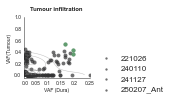

In [11]:
### 1. Overlay figure for PCs
print ("## Decomposed - FacetCNV for Positive Control (PC)s")
Sample_IDs = ["221026", "240110", "241127", "250207_Ant"]
TISSUEs = ["Dura", "Dura", "Falx_1", "Dura_Ant"]
kwargs = { "figsize": (1.25, 1.25), "xlabel_fontsize": 5, "ylabel_fontsize": 5, "title_fontsize": 6, "title_fontweight": "bold", "tick_labelsize" : 5, "pad_label" : 2, "pad_tick" : -1, "spine_linewidth" : 0.5,
                "scatter_alpha" : 0.7,   "scatter_size": 15,  "shapelist" : ["o"] * len(Sample_IDs), "colorlist" : colorlist_PC, "label" : "Sample_ID",     # "shapelist" : ["o", "s", "^", "v", ">", "<"]
                "driver_linewidth" : 0.2, "driver_edgecolor" : "#5CB270",
                "kde_levels" : 3, "kde_linewidth" : 0.5, "kde_alpha" : 0.5, "kde_color" : "gray",
                "legend_markerscale" : 0.6, "legend_fontsize" : 8,
                "spine_offset" : 5,
                "OUTPUT_SUPTITLE" : "Tumour infiltration", "MULTIPLIER" : 0.75, "OUTPUT_VIS_FIG1" : f"{PYCLONEVIpath}/02.pyclonevi/overlay/PC.visualization.pdf" }
os.makedirs(os.path.dirname(kwargs["OUTPUT_VIS_FIG1"]), exist_ok = True)

fig, ax = plt.subplots( figsize = kwargs["figsize"], nrows = 1, ncols = 1 )
fig.subplots_adjust (wspace = 0.15, hspace = 0.1, bottom = 0.20, top = 0.88, left = 0.23, right = 0.96)
ax.set_xlim([ -0.0125,  0.5]); ax.set_ylim([ -0.05,  1.0])
ax.set_title( kwargs["OUTPUT_SUPTITLE"], fontsize = kwargs["title_fontsize"], fontweight = 'bold')
ax.set_xlabel("VAF (Dura)", fontdict = {"fontsize" : kwargs ["xlabel_fontsize"] }, labelpad = kwargs["pad_label"] )
ax.set_ylabel("VAF(Tumour)", fontdict = {"fontsize" : kwargs ["ylabel_fontsize"] }, labelpad = kwargs["pad_label"] )

for i, Sample_ID in enumerate( Sample_IDs ) :
    TISSUE = TISSUEs[i]
    #sequenza_to_pyclonevi_matrix_path = f"{PYCLONEVIpath}/01.make_matrix/{Sample_ID}/{Sample_ID}.sequenza_to_pyclonevi.tsv"
    #sequenza_to_pyclonevi_output_path = f"{PYCLONEVIpath}/02.pyclonevi/{Sample_ID}/{Sample_ID}.sequenza_to_pyclonevi.tsv"
    FACETCNV_TO_PYCLONEVI_MATRIX_PATH = f"{PYCLONEVIpath}/01.make_matrix/{Sample_ID}/{Sample_ID}_{TISSUE}.facetcnv_to_pyclonevi.tsv"
    FACETCNV_TO_PYCLONEVI_OUTPUT_PATH = f"{PYCLONEVIpath}/02.pyclonevi/{Sample_ID}/{Sample_ID}_{TISSUE}.facetcnv_to_pyclonevi.tsv"    
    OUTPUT_VIS_DF = f"{PYCLONEVIpath}/02.pyclonevi/{Sample_ID}/{Sample_ID}_{TISSUE}.visualization_df.tsv"


    df_facet_to_pycl = pd.read_csv (FACETCNV_TO_PYCLONEVI_OUTPUT_PATH, sep = "\t")
    df_facet_to_pycl = df_facet_to_pycl.drop_duplicates (['mutation_id'], keep = 'first') [ [ "mutation_id", "cluster_id"] ].reset_index().drop ('index', axis = 1)
    df_facet_matrix = pd.read_csv (FACETCNV_TO_PYCLONEVI_MATRIX_PATH, sep = "\t")   

    # FacetCNV visualization
    df_facet_integrated = pd.merge (df_facet_matrix, df_facet_to_pycl, left_on = "mutation_id", right_on = "mutation_id")
    
    kwargs.update ( { "Sample_ID" : Sample_ID,  "i" : i }  )
    df, ax = visualization_decomposition ( df_facet_integrated, ax, **kwargs )
    fig.savefig ( kwargs["OUTPUT_VIS_FIG1"], dpi = 300 )


In [12]:
df_facet_integrated [df_facet_integrated["gene"] == "NF2"]

,mutation_id,sample_id,ref_counts,alt_counts,normal_cn,major_cn,minor_cn,tumour_content,types,gene,variant_classification,cluster_id,CHR,POS,ALT,REF
224,chr22_29655663_C_T,250207_Ant_Dura,282,57,2,1,0,0.34,Mutect2,NF2,stop_gained,0,chr22,29655663,C,T
225,chr22_29655663_C_T,250207_Ant_Tumor,47,53,2,1,0,0.60,Mutect2,NF2,stop_gained,0,chr22,29655663,C,T


## Decomposed - FacetCNV for Shared drivers (PT)s ( n = 22 )
190426_FFT_Dura NF2 0.088 289 28 0.5 29 29
190426_PCT_Dura NF2 0.088 289 28 0.509 28 29
190426_PFT_Dura NF2 0.088 289 28 0.395 52 34
190426_PP_Dura NF2 0.088 289 28 0.413 37 26
190426_PT_Dura NF2 0.088 289 28 0.603 29 44
220930_2_Dura NF2 0.023 374 9 0.487 81 77
221102_Dura NF2 0.0007 39 0 0.49 39 38
221202_Dura AKT1 0.0 55 0 0.409 55 38
221202_Dura TRAF7 0.0 76 0 0.377 76 46
230127_Dura NF2 0.0 54 0 0.526 54 60
230323_2_Dura NF2 0.062 270 18 0.265 36 13
230323_11_Dura NF2 0.062 270 18 0.409 65 45
230405_2_Dura KLF4 0.019 359 7 0.333 94 47
230405_2_Dura TRAF7 0.031 476 15 0.354 113 62
230419_Dura NF2 0.007 303 2 0.613 46 73
230822_Dura NF2 0.006 177 1 0.568 35 46
230920_Dura NF2 0.003 398 1 0.619 40 65
230802_2_Dura NF2 0.003 317 1 0.647 12 22
240403_3_Dura NF2 0.002 70 0 0.29 70 28
240412_2_Dura NF2 0.003 22 0 0.46 22 22
241023_Dura NF2 0.0002 18 0 0.79 18 67
190524_Dura NF2 0.041 639 1 0.43 68 49
240320_Dura NF2 0.007 458 3

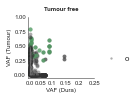

In [13]:
### 2. Overlay figure for PTs
print ("## Decomposed - FacetCNV for Shared drivers (PT)s ( n = 22 )")
Sample_IDs = [ "190426_FFT", "190426_PCT", "190426_PFT", "190426_PP", "190426_PT", "220930_2", "221102", "221202", "230127", "230323_2", "230323_11",
                        "230405_2", "230419", "230822", "230920", "230802_2", "240403_3", "240412_2", "241023", "190524", "240320", "231025"  ]
TISSUEs = ["Dura"] * len(Sample_IDs)
kwargs = { "figsize": (1.25, 1.25), "xlabel_fontsize": 6, "ylabel_fontsize": 6, "title_fontsize": 6, "title_fontweight": "bold", "tick_labelsize" : 6, "pad_label" : 2, "pad_tick" : -1, "spine_linewidth" : 0.5,
                "scatter_alpha" : 0.4,   "scatter_size": 15, "shapelist" : ["o"] * len(Sample_IDs ),  #"shapelist" : ["o"] * 5  + ["s"] * 4 + ["o"] * 2 + ["s"] * 4 + ["o"] + ["s"] * 6, 
                "colorlist" : colorlist_PT,  "label" : "shape",
                "driver_linewidth" : 0.2, "driver_edgecolor" : "#5CB270",
                "kde_levels" : 1,  "kde_linewidth" : 0.5, "kde_alpha" : 0.5, "kde_color" : "gray",
                "legend_markerscale" : 0.6, "legend_fontsize" : 8, "MULTIPLIER" : 0.75,
                "OUTPUT_SUPTITLE" : "Tumour free", "OUTPUT_VIS_FIG" : f"{PYCLONEVIpath}/02.pyclonevi/overlay/PT.visualization.pdf" }
os.makedirs(os.path.dirname( kwargs["OUTPUT_VIS_FIG"]), exist_ok = True)

fig, ax = plt.subplots( figsize = kwargs["figsize"], nrows = 1, ncols = 1 )
fig.subplots_adjust (wspace = 0.15, hspace = 0.1, bottom = 0.20, top = 0.88, left = 0.23, right = 0.96)
ax.set_title( kwargs["OUTPUT_SUPTITLE"], fontsize = kwargs["title_fontsize"], fontweight = 'bold')
ax.set_xlabel("VAF (Dura)", fontdict = {"fontsize" : kwargs ["xlabel_fontsize"] }, labelpad = kwargs["pad_label"] )
ax.set_ylabel("VAF (Tumour)", fontdict = {"fontsize" : kwargs ["ylabel_fontsize"] }, labelpad = kwargs["pad_label"] )
ax.set_xlim([-0.0125,  0.5]); ax.set_ylim([ -0.05,  1.0])


for i, Sample_ID in enumerate( Sample_IDs ) :
    TISSUE=TISSUEs[i]
    FACETCNV_TO_PYCLONEVI_MATRIX_PATH = f"{PYCLONEVIpath}/01.make_matrix/{Sample_ID}/{Sample_ID}_{TISSUE}.facetcnv_to_pyclonevi.tsv"
    FACETCNV_TO_PYCLONEVI_OUTPUT_PATH = f"{PYCLONEVIpath}/02.pyclonevi/{Sample_ID}/{Sample_ID}_{TISSUE}.facetcnv_to_pyclonevi.tsv"

    df_facet_to_pycl = pd.read_csv (FACETCNV_TO_PYCLONEVI_OUTPUT_PATH, sep = "\t")
    df_facet_to_pycl = df_facet_to_pycl.drop_duplicates (['mutation_id'], keep = 'first') [ [ "mutation_id", "cluster_id"] ].reset_index().drop ('index', axis = 1)
    df_facet_matrix = pd.read_csv (FACETCNV_TO_PYCLONEVI_MATRIX_PATH, sep = "\t")   

    # FacetCNV visualization
    df_facet_integrated = pd.merge (df_facet_matrix, df_facet_to_pycl, left_on = "mutation_id", right_on = "mutation_id")
    
    kwargs.update ( { "Sample_ID" : Sample_ID,  "i" : i}  )
    df, ax = visualization_decomposition ( df_facet_integrated, ax, **kwargs )
    fig.savefig ( kwargs["OUTPUT_VIS_FIG"], dpi = 300 )


In [8]:
df_facet_integrated

,mutation_id,sample_id,ref_counts,alt_counts,normal_cn,major_cn,minor_cn,tumour_content,types,gene,variant_classification,cluster_id,CHR,POS,ALT,REF
0,chr1_197090267_G_A,241127_Dura,103,1,2,1,1,1.00,Mutect2,ASPM,missense_variant,1,chr1,197090267,G,A
1,chr1_197090267_G_A,241127_Tumor,150,39,2,1,1,0.55,Mutect2,ASPM,missense_variant,1,chr1,197090267,G,A
2,chr1_43991705_G_A,241127_Dura,64,2,2,1,1,1.00,Mutect2,B4GALT2,downstream_gene_variant,1,chr1,43991705,G,A
3,chr1_43991705_G_A,241127_Tumor,118,36,2,1,1,0.55,Mutect2,B4GALT2,downstream_gene_variant,1,chr1,43991705,G,A
4,chr3_124766347_T_C,241127_Dura,129,0,2,1,1,1.00,Mutect2,ITGB5,splice_acceptor_variant,1,chr3,124766347,T,C
5,chr3_124766347_T_C,241127_Tumor,129,35,2,1,1,0.55,Mutect2,ITGB5,splice_acceptor_variant,1,chr3,124766347,T,C
6,chr5_141245873_A_G,241127_Dura,97,0,2,1,1,1.00,Mutect2,PCDHB15,missense_variant,2,chr5,141245873,A,G
7,chr5_141245873_A_G,241127_Tumor,97,5,2,1,1,0.55,Mutect2,PCDHB15,missense_variant,2,chr5,141245873,A,G
8,chr6_37459583_G_A,241127_Dura,24,8,2,1,1,1.00,Mutect2,CMTR1,missense_variant,3,chr6,37459583,G,A
9,chr6_37459583_G_A,241127_Tumor,24,0,2,1,1,0.55,Mutect2,CMTR1,missense_variant,3,chr6,37459583,G,A


In [ ]:
"chr22_29673302_G_GAA" 0.0002
"chr22_29639185_G_GA" 0.0007
"chr22_29636785_TG_T"  0.002
"chr22_29655663_C_T" = 0.003
"chr22_29604167_A _AGGTT" 0.0002
"chr22_29661313_C_T"  = 0.041
"chr22_29654656_G_A"   0.003